## 모델 구현

- ResNet-34와 ResNet-50에서 사용된 블록들 비교
   - 블럭을 각각 3, 4, 6, 3 개씩 쌓은 형식으로 동일하다
   - ResNet-34: 3x3 conv layer만 사용 (Basic Block)
   - ResNet-50: 1x1 conv가 앞 뒤로 붙어 더 많은 conv layer를 갖는다 (Bottleneck Block)
   - **즉, VGG-16,19와 달리 ResNet-34,50은 블록 함수를 각각 정의해야 한다**

In [1]:
# 사용할 라이브러리 버전 확인

import torch
import numpy as np

print(torch.__version__)
print(np.__version__)

2.7.1+cu118
2.2.6


### ResNet-34 블록 클래스

In [2]:
# function for building ResNet-34 Block

import torch.nn as nn

class BasicBlock(nn.Module):
    expansion =1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # first conv + BN + ReLU
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # second conv + BN
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # skip connection을 위한 downsample (크기나 채널이 다를 경우 맞춰준다)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 만약 크기나 채널이 달라졌다면 identity도 맞춰주기
        if self.downsample is not None:
            identity = self.downsample(identity)

        out += identity

        out = self.relu(out)

        return out

### ResNet-50 블록 클래스

- conv-BN-ReLU 순 (original)
  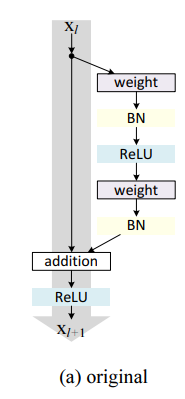

In [3]:
# function for building ResNet-34 Block

import torch.nn as nn

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # first conv + BN + ReLU
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # second conv + BN + ReLU
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # third conv + BN
        self.conv3 = nn.Conv2d(out_channels, out_channels*4, kernel_size=1, stride=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels*4)
        
        # skip connection을 위한 downsample (크기나 채널이 다를 경우 맞춰준다)
        self.downsample = None
        if stride != 1 or in_channels != out_channels*self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels*4, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels*4)
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # 만약 크기나 채널이 달라졌다면 identity도 맞춰주기
        if self.downsample is not None:
            identity = self.downsample(identity)

        out += identity

        out = self.relu(out)

        return out

### ResNet 클래스

In [4]:
# ResNet 모델 자체를 생성하는 클래스
class ResNet(nn.Module):
    def __init__(self, block, num_blocks=[3,4,6,3], num_classes=1000):
        super().__init__()

        self.in_channels = 64

        # stem layer- 7x7 conv + max pooling
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 블록 쌓기
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # final layer - avg pooling + fully connected
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc =nn.Linear(512 * block.expansion, num_classes)
        
    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers=[]

        # first block: 크기 축소 및 채널 확장
        layers.append(block(self.in_channels,out_channels, stride))

        # 변수 값을 업데이트
        self.in_channels = out_channels * block.expansion

        # lefts: 앞서 만들어진 크기와 채널을 그대로 유지하며 반
        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        # stem layer
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # 4 stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # final layer
        x = self.avgpool(x)
        x = torch.flatten(x,1)
        x = self.fc(x)

        return x

### build_resnet()

In [5]:
def build_resnet(resnet_version, num_classes=1000):
    if resnet_version == 34:
        return ResNet(block=BasicBlock, num_blocks=[3,4,6,3], num_classes=num_classes)

    elif resnet_version == 50:
        return ResNet(block=Bottleneck, num_blocks=[3,4,6,3], num_classes=num_classes)

    else:
        raise ValueError("ResNet-34, ResNet-50만 지원합니다")

### 모델 생성 함수

In [10]:
!pip install torchinfo
from torchinfo import summary

In [63]:
resnet_34 = build_resnet(34, 1000)
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [65]:
resnet_50 = build_resnet(50, 1000)
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

### 224x224 픽셀 크기의 데이터셋을 불러오자.

In [6]:
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [68]:
transform = transforms.Compose([
    transforms.Resize((224,224)), # 모든 이미지를 224x224로 통일
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
# 데이터셋 경로를 바꾸고 싶다면, root 인자 확인
# OxfordIIITPet 클래스에서는 train 대신 split이라는 인자를 사용한다
# trainval은 train+validation 세트라서 이를 분리해서 사용해야 하지만,
# 위에서 다룬 CIFAR10은 validation을 따로 제공하지 않아 train, test set을 이용했으므로
# 여기서도 동일하게 train(trainval), test set을 사용하였다
trainset = torchvision.datasets.OxfordIIITPet(root='./data', split="trainval", download=True, transform=transform)
testset = torchvision.datasets.OxfordIIITPet(root='./data', split="test", download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

In [48]:
# 데이터셋을 로드하고 기본 정보를 확인
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 224, 224])
Label: 0
Number of classes: 37


In [49]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 3680 (Shape: torch.Size([]))
Test dataset size: 3669 (Shape: torch.Size([]))


In [50]:
# 데이터 정규화
transform = transforms.Compose([
    transforms.ToTensor()  
    # ToTensor함수에 입력 데이터가 uint8 인 경우 → float32 변환 + 0~1 정규화
])

In [51]:
# 데이터셋 정보 확인하기
num_classes = len(trainset.classes)
print(num_classes)

37


In [52]:
class_names = trainset.classes
print(class_names)

['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [53]:
# 시각화 함수
def imshow(img):
    img = img / 2 + 0.5 # 이미지 시각화를 위한 역정규화 (평균,표준편차 = 0.5인 경우)
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

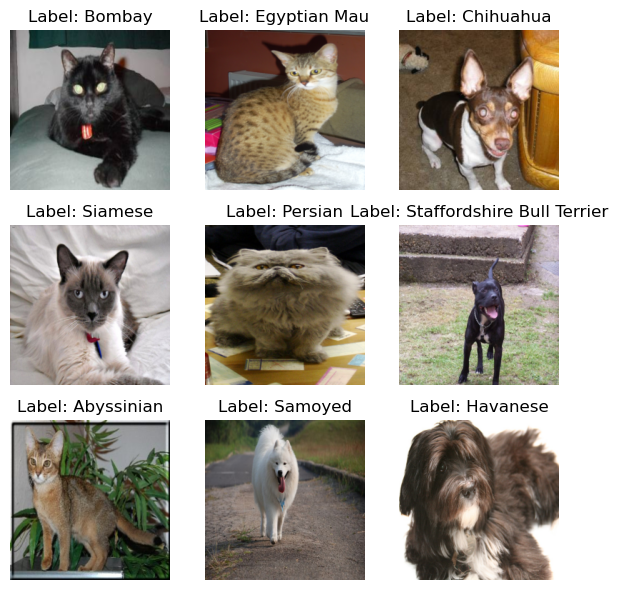

In [54]:
show_multiple_images(trainloader)

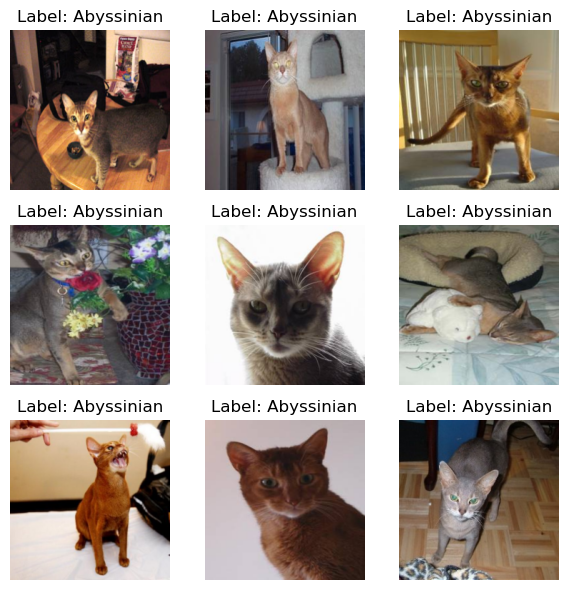

In [55]:
show_multiple_images(testloader)

## 시각화

## 학습 진행

In [67]:
BATCH_SIZE = 256
EPOCH = 15 #확인을 위한 정도의 epoch로 설정

In [90]:
# ResNet-34
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ResNet_34 = build_resnet(34, 37) # Oxford-IIIT Pet 데이터셋 (37개 클래스)
ResNet_34.to(device)

for param in ResNet_34.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(ResNet_34.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

ResNet_34_train_losses = []
ResNet_34_val_accuracy = []
ResNet_34_val_losses = []

for epoch in range(EPOCH):
    ResNet_34.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ResNet_34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    ResNet_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

    ResNet_34.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = ResNet_34(inputs)

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_running_loss / len(testloader)
    val_acc = 100 * correct / total

    ResNet_34_val_losses.append(val_loss)
    ResNet_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Val Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

[1,   100] loss: 4.622
Epoch 1: Train Loss: 3.5742, Train Accuracy: 4.81%
Epoch 1: Val Loss: 3.4749, Validation Accuracy: 7.33%
[2,   100] loss: 4.280
Epoch 2: Train Loss: 3.2410, Train Accuracy: 12.47%
Epoch 2: Val Loss: 3.3973, Validation Accuracy: 9.51%
[3,   100] loss: 4.023
Epoch 3: Train Loss: 2.9831, Train Accuracy: 18.15%
Epoch 3: Val Loss: 3.3410, Validation Accuracy: 12.32%
[4,   100] loss: 3.750
Epoch 4: Train Loss: 2.7107, Train Accuracy: 24.59%
Epoch 4: Val Loss: 3.0526, Validation Accuracy: 15.84%
[5,   100] loss: 3.462
Epoch 5: Train Loss: 2.4511, Train Accuracy: 30.68%
Epoch 5: Val Loss: 3.0554, Validation Accuracy: 16.65%
[6,   100] loss: 3.171
Epoch 6: Train Loss: 2.1658, Train Accuracy: 37.72%
Epoch 6: Val Loss: 3.9593, Validation Accuracy: 13.90%
[7,   100] loss: 2.843
Epoch 7: Train Loss: 1.8362, Train Accuracy: 47.58%
Epoch 7: Val Loss: 4.0336, Validation Accuracy: 14.66%
[8,   100] loss: 2.424
Epoch 8: Train Loss: 1.4245, Train Accuracy: 59.27%
Epoch 8: Val Loss:

In [85]:
# ResNet-50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ResNet_50 = build_resnet(50, 37) # Oxford-IIIT Pet 데이터셋 (37개 클래스)
ResNet_50.to(device)

for param in ResNet_50.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(ResNet_50.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

ResNet_50_train_losses = []
ResNet_50_val_accuracy = []
ResNet_50_val_losses = []

for epoch in range(EPOCH):
    ResNet_50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ResNet_50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    ResNet_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

    ResNet_50.eval()
    correct = 0
    total = 0
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = ResNet_50(inputs)

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(testloader)
    val_acc = 100 * correct / total
    
    ResNet_50_val_losses.append(val_loss)
    ResNet_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Val Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

[1,   100] loss: 4.785
Epoch 1: Train Loss: 3.7416, Train Accuracy: 2.83%
Epoch 1: Val Loss: 3.9106, Validation Accuracy: 3.54%
[2,   100] loss: 4.671
Epoch 2: Train Loss: 3.6207, Train Accuracy: 5.41%
Epoch 2: Val Loss: 3.6607, Validation Accuracy: 5.83%
[3,   100] loss: 4.500
Epoch 3: Train Loss: 3.4584, Train Accuracy: 8.53%
Epoch 3: Val Loss: 3.5684, Validation Accuracy: 6.73%
[4,   100] loss: 4.301
Epoch 4: Train Loss: 3.2670, Train Accuracy: 11.66%
Epoch 4: Val Loss: 3.3828, Validation Accuracy: 9.95%
[5,   100] loss: 4.158
Epoch 5: Train Loss: 3.1281, Train Accuracy: 15.22%
Epoch 5: Val Loss: 3.4122, Validation Accuracy: 11.88%
[6,   100] loss: 3.978
Epoch 6: Train Loss: 2.9632, Train Accuracy: 18.42%
Epoch 6: Val Loss: 3.4356, Validation Accuracy: 11.80%
[7,   100] loss: 3.790
Epoch 7: Train Loss: 2.7663, Train Accuracy: 22.23%
Epoch 7: Val Loss: 3.3112, Validation Accuracy: 14.69%
[8,   100] loss: 3.584
Epoch 8: Train Loss: 2.5691, Train Accuracy: 27.88%
Epoch 8: Val Loss: 3.2

### Training Set

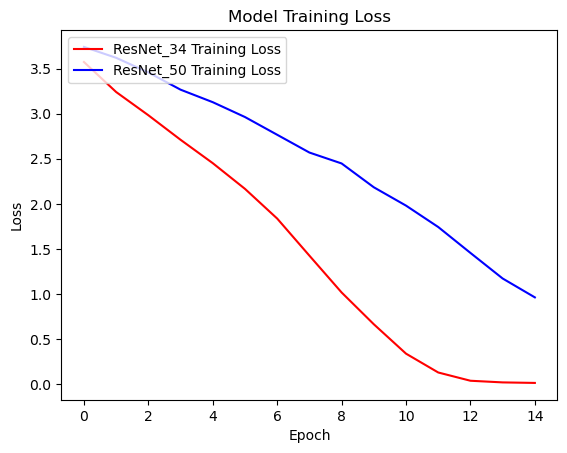

In [91]:
plt.plot(ResNet_34_train_losses, 'r', label="ResNet_34 Training Loss")
plt.plot(ResNet_50_train_losses, 'b', label="ResNet_50 Training Loss")

plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

### Test Set

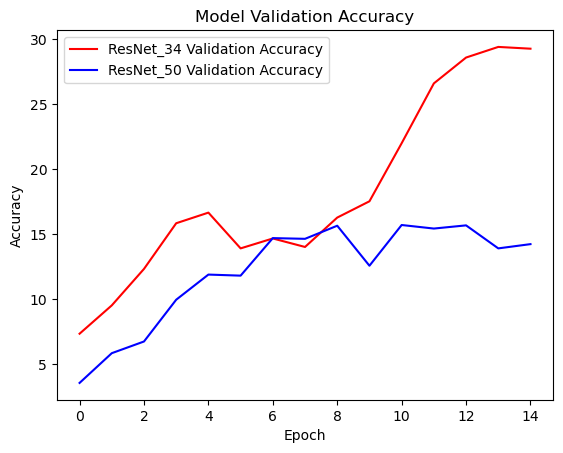

In [92]:
plt.plot(ResNet_34_val_accuracy, 'r', label="ResNet_34 Validation Accuracy")
plt.plot(ResNet_50_val_accuracy, 'b', label="ResNet_50 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

## Ablation Study

### Plain-34

In [76]:
class PlainBasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        # identity 백업과 덧셈이 모두 사라지고 일직선으로만 흐름
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        return out

### Plain-50

In [77]:
class PlainBottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.relu(out) # 덧셈 없이 바로 통과

        return out

### build_plainnet

In [78]:
def build_plainnet(resnet_version, num_classes=1000):
    if resnet_version == 34:
        return ResNet(block=PlainBasicBlock, num_blocks=[3,4,6,3], num_classes=num_classes)

    elif resnet_version == 50:
        return ResNet(block=PlainBottleneck, num_blocks=[3,4,6,3], num_classes=num_classes)

    else:
        raise ValueError("ResNet-34, ResNet-50만 지원합니다")

### Plain 모델 학습

In [79]:
# PlainNet-34
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PlainNet_34 = build_plainnet(34, 37) # Oxford-IIIT Pet 데이터셋 (37개 클래스)
PlainNet_34.to(device)

for param in PlainNet_34.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(PlainNet_34.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

PlainNet_34_train_losses = []
PlainNet_34_val_accuracy = []
PlainNet_34_val_losses = []

for epoch in range(EPOCH):
    PlainNet_34.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = PlainNet_34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    PlainNet_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

    PlainNet_34.eval()
    correct = 0
    total = 0
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = PlainNet_34(inputs)

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(testloader)
    val_acc = 100 * correct / total

    PlainNet_34_val_losses.append(val_loss)
    PlainNet_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Val Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

[1,   100] loss: 4.672
Epoch 1: Train Loss: 3.6324, Train Accuracy: 2.64%
Epoch 1: Val Loss: 3.6371, Validation Accuracy: 3.90%
[2,   100] loss: 4.585
Epoch 2: Train Loss: 3.5405, Train Accuracy: 5.87%
Epoch 2: Val Loss: 3.6773, Validation Accuracy: 5.86%
[3,   100] loss: 4.478
Epoch 3: Train Loss: 3.4418, Train Accuracy: 7.64%
Epoch 3: Val Loss: 3.4403, Validation Accuracy: 7.52%
[4,   100] loss: 4.383
Epoch 4: Train Loss: 3.3428, Train Accuracy: 9.84%
Epoch 4: Val Loss: 3.4305, Validation Accuracy: 7.03%
[5,   100] loss: 4.291
Epoch 5: Train Loss: 3.2608, Train Accuracy: 11.30%
Epoch 5: Val Loss: 3.3492, Validation Accuracy: 9.21%
[6,   100] loss: 4.209
Epoch 6: Train Loss: 3.1745, Train Accuracy: 12.64%
Epoch 6: Val Loss: 3.2683, Validation Accuracy: 10.49%
[7,   100] loss: 4.138
Epoch 7: Train Loss: 3.1116, Train Accuracy: 14.05%
Epoch 7: Val Loss: 3.2644, Validation Accuracy: 10.60%
[8,   100] loss: 4.037
Epoch 8: Train Loss: 3.0153, Train Accuracy: 16.01%
Epoch 8: Val Loss: 3.306

In [80]:
# PlainNet-50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PlainNet_50 = build_plainnet(50, 37) # Oxford-IIIT Pet 데이터셋 (37개 클래스)
PlainNet_50.to(device)

for param in PlainNet_50.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(PlainNet_50.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

PlainNet_50_train_losses = []
PlainNet_50_val_accuracy = []
PlainNet_50_val_losses = []

for epoch in range(EPOCH):
    PlainNet_50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = PlainNet_50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    PlainNet_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

    PlainNet_50.eval()
    correct = 0
    total = 0
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = PlainNet_50(inputs)

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(testloader)
    val_acc = 100 * correct / total

    PlainNet_50_val_losses.append(val_loss)
    PlainNet_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Val Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

[1,   100] loss: 4.682
Epoch 1: Train Loss: 3.6469, Train Accuracy: 2.64%
Epoch 1: Val Loss: 3.7017, Validation Accuracy: 2.89%
[2,   100] loss: 4.671
Epoch 2: Train Loss: 3.6337, Train Accuracy: 2.93%
Epoch 2: Val Loss: 3.6636, Validation Accuracy: 3.24%
[3,   100] loss: 4.653
Epoch 3: Train Loss: 3.6109, Train Accuracy: 3.51%
Epoch 3: Val Loss: 3.6449, Validation Accuracy: 4.03%
[4,   100] loss: 4.607
Epoch 4: Train Loss: 3.5708, Train Accuracy: 4.84%
Epoch 4: Val Loss: 3.6201, Validation Accuracy: 4.50%
[5,   100] loss: 4.558
Epoch 5: Train Loss: 3.5263, Train Accuracy: 5.65%
Epoch 5: Val Loss: 3.5436, Validation Accuracy: 5.15%
[6,   100] loss: 4.518
Epoch 6: Train Loss: 3.4835, Train Accuracy: 6.44%
Epoch 6: Val Loss: 3.5633, Validation Accuracy: 5.97%
[7,   100] loss: 4.478
Epoch 7: Train Loss: 3.4411, Train Accuracy: 6.85%
Epoch 7: Val Loss: 3.5294, Validation Accuracy: 5.94%
[8,   100] loss: 4.439
Epoch 8: Train Loss: 3.3986, Train Accuracy: 7.39%
Epoch 8: Val Loss: 3.4308, Val

### 시각화

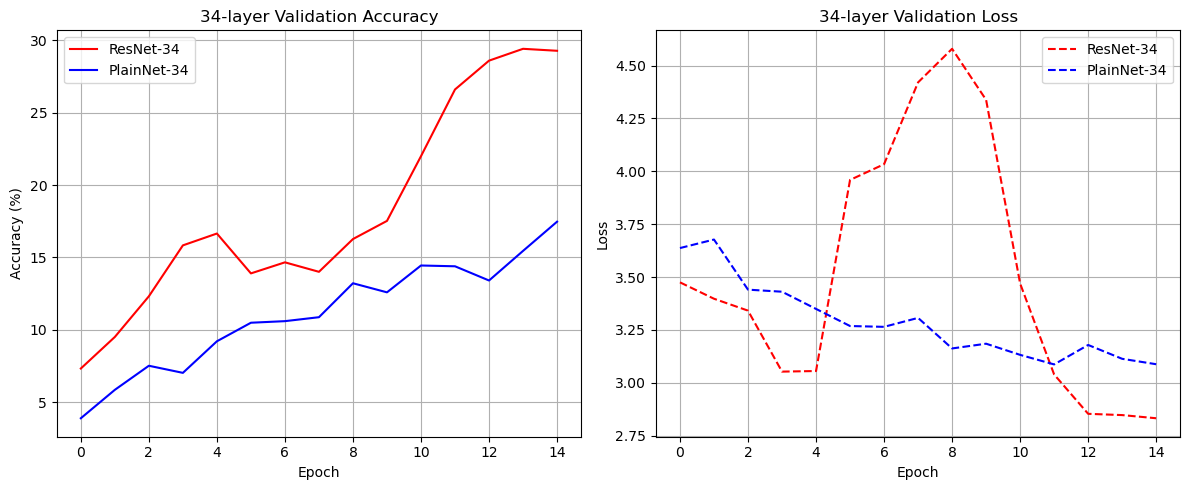

In [93]:
import matplotlib.pyplot as plt

# 34-layer 비교
plt.figure(figsize=(12, 5))

# Validation Accuracy 그래프
plt.subplot(1, 2, 1)
plt.plot(ResNet_34_val_accuracy, 'r-', label="ResNet-34")
plt.plot(PlainNet_34_val_accuracy, 'b-', label="PlainNet-34")
plt.title('34-layer Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Validation Loss 그래프
plt.subplot(1, 2, 2)
plt.plot(ResNet_34_val_losses, 'r--', label="ResNet-34")
plt.plot(PlainNet_34_val_losses, 'b--', label="PlainNet-34")
plt.title('34-layer Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

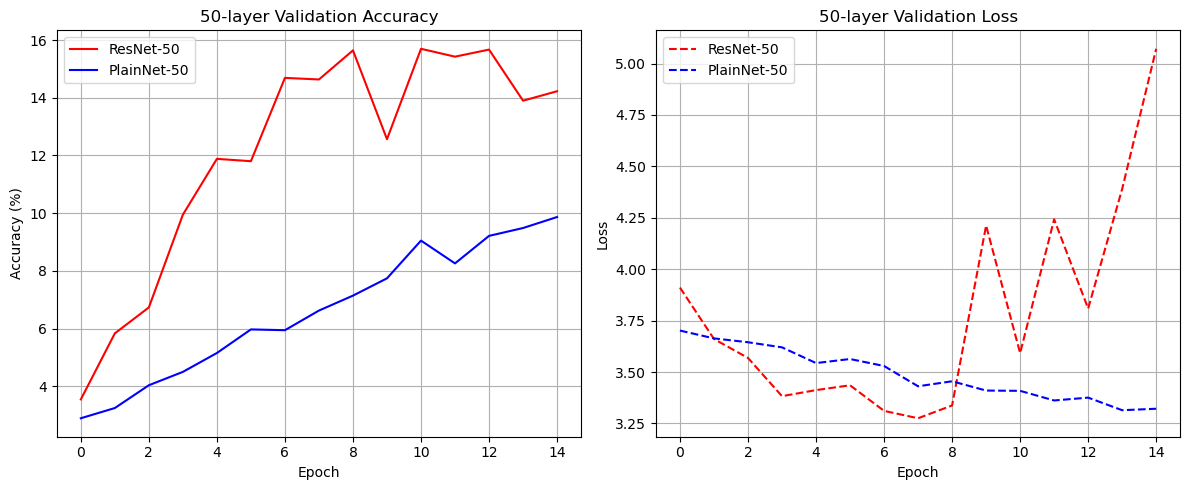

In [94]:
# 50-layer 비교
plt.figure(figsize=(12, 5))

# Validation Accuracy 그래프
plt.subplot(1, 2, 1)
plt.plot(ResNet_50_val_accuracy, 'r-', label="ResNet-50")
plt.plot(PlainNet_50_val_accuracy, 'b-', label="PlainNet-50")
plt.title('50-layer Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# 2. Validation Loss 그래프
plt.subplot(1, 2, 2)
plt.plot(ResNet_50_val_losses, 'r--', label="ResNet-50")
plt.plot(PlainNet_50_val_losses, 'b--', label="PlainNet-50")
plt.title('50-layer Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [84]:
print(f"ResNet-34: {len(ResNet_34_val_losses)}, PlainNet-34: {len(PlainNet_34_val_losses)}")
print(f"ResNet-50: {len(ResNet_50_val_losses)}, PlainNet-50: {len(PlainNet_50_val_losses)}")


ResNet-34: 30, PlainNet-34: 15
ResNet-50: 0, PlainNet-50: 15


### 결과표 (validation accuracy 기준)

|Model Name|Skip Connection|Validation Accuracy|
|----------|---------------|-------------------|
| Plain-34 |      X       |       17.47%      |
| ResNet-34 |     O       |       29.27%      |
| Plain-50 |      X       |       9.87        |
| ResNet-50 |     O       |       14.23%      |

## 추가 실험 (1)
- torchvision의 CIFAR100 데이터세트 사용
- 에폭 수 30

In [26]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Transform 정의 (Resize 224가 핵심!)
# 학습용: 데이터 증강(Augmentation) 포함
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # 모델 규격에 맞춤
    transforms.RandomHorizontalFlip(),  # 좌우 반전으로 데이터 뻥튀기
    transforms.RandomRotation(10),      # 살짝 회전시켜서 다양성 확보
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1] 정규화
])

# 검증/테스트용: 증강 없이 정규화만
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. 데이터셋 로드 (CIFAR-100)
train_dataset = datasets.CIFAR100(
    root="./data", 
    train=True, 
    download=True, 
    transform=train_transform
)

test_dataset = datasets.CIFAR100(
    root="./data", 
    train=False, 
    download=True, 
    transform=test_transform
)

# 3. 데이터로더 설정
batch_size = 64 # 메모리 사양에 따라 32~128 조절
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"테스트 데이터 개수: {len(test_dataset)}")


학습 데이터 개수: 50000
테스트 데이터 개수: 10000


In [27]:
BATCH_SIZE = 256
EPOCH = 30

In [28]:
# ResNet-34
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ResNet_34 = build_resnet(34, 100)
ResNet_34.to(device)

for param in ResNet_34.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(ResNet_34.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

ResNet_34_train_losses = []
ResNet_34_val_accuracy = []
ResNet_34_val_losses = []

for epoch in range(EPOCH):
    ResNet_34.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ResNet_34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    ResNet_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

    ResNet_34.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = ResNet_34(inputs)

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_running_loss / len(testloader)
    val_acc = 100 * correct / total

    ResNet_34_val_losses.append(val_loss)
    ResNet_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Val Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 

RuntimeError: DataLoader worker (pid(s) 806, 807) exited unexpectedly

In [29]:
# ResNet-50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ResNet_50 = build_resnet(50, 100)
ResNet_50.to(device)

for param in ResNet_50.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(ResNet_50.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

ResNet_50_train_losses = []
ResNet_50_val_accuracy = []
ResNet_50_val_losses = []

for epoch in range(EPOCH):
    ResNet_50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ResNet_50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    ResNet_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

    ResNet_50.eval()
    correct = 0
    total = 0
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = ResNet_50(inputs)

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(testloader)
    val_acc = 100 * correct / total
    
    ResNet_50_val_losses.append(val_loss)
    ResNet_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Val Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 

RuntimeError: DataLoader worker (pid(s) 811) exited unexpectedly

## 추가 실험 (2)
- torchvision의 CIFAR10 데이터세트 사용
- 에폭 수 30 

In [30]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Transform 정의 (속도와 성능의 타협점 64x64)
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),        # 224보다 훨씬 빠름
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 표준 정규화
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 2. 데이터셋 로드 (CIFAR-10으로 변경)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# 3. 데이터로더 설정 (에러 방지를 위해 num_workers=0)
batch_size = 128 # 64보다 조금 더 키워서 속도 향상
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(trainset)}개, 클래스: 10개")


학습 데이터: 50000개, 클래스: 10개


In [20]:
# ResNet-34
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ResNet_34 = build_resnet(34, 10)
ResNet_34.to(device)

for param in ResNet_34.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(ResNet_34.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

ResNet_34_train_losses = []
ResNet_34_val_accuracy = []
ResNet_34_val_losses = []

for epoch in range(EPOCH):
    ResNet_34.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ResNet_34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    ResNet_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

    ResNet_34.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = ResNet_34(inputs)

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_running_loss / len(testloader)
    val_acc = 100 * correct / total

    ResNet_34_val_losses.append(val_loss)
    ResNet_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Val Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

[1,   100] loss: 2.867
[1,   200] loss: 2.683
[1,   300] loss: 2.572
Epoch 1: Train Loss: 1.4954, Train Accuracy: 45.31%
Epoch 1: Val Loss: 1.3057, Validation Accuracy: 52.47%
[2,   100] loss: 2.162
[2,   200] loss: 2.133
[2,   300] loss: 2.102
Epoch 2: Train Loss: 1.0769, Train Accuracy: 61.47%
Epoch 2: Val Loss: 1.0395, Validation Accuracy: 62.69%
[3,   100] loss: 1.909
[3,   200] loss: 1.903
[3,   300] loss: 1.897
Epoch 3: Train Loss: 0.8804, Train Accuracy: 68.93%
Epoch 3: Val Loss: 0.8974, Validation Accuracy: 68.47%
[4,   100] loss: 1.746
[4,   200] loss: 1.740
[4,   300] loss: 1.742
Epoch 4: Train Loss: 0.7369, Train Accuracy: 73.99%
Epoch 4: Val Loss: 0.8771, Validation Accuracy: 69.54%
[5,   100] loss: 1.624
[5,   200] loss: 1.630
[5,   300] loss: 1.636
Epoch 5: Train Loss: 0.6318, Train Accuracy: 78.01%
Epoch 5: Val Loss: 0.8128, Validation Accuracy: 72.21%
[6,   100] loss: 1.532
[6,   200] loss: 1.543
[6,   300] loss: 1.549
Epoch 6: Train Loss: 0.5480, Train Accuracy: 80.71%

In [21]:
# ResNet-50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ResNet_50 = build_resnet(50, 10)
ResNet_50.to(device)

for param in ResNet_50.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(ResNet_50.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

ResNet_50_train_losses = []
ResNet_50_val_accuracy = []
ResNet_50_val_losses = []

for epoch in range(EPOCH):
    ResNet_50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ResNet_50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    ResNet_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

    ResNet_50.eval()
    correct = 0
    total = 0
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = ResNet_50(inputs)

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(testloader)
    val_acc = 100 * correct / total
    
    ResNet_50_val_losses.append(val_loss)
    ResNet_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Val Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

[1,   100] loss: 3.181
[1,   200] loss: 2.971
[1,   300] loss: 2.855
Epoch 1: Train Loss: 1.7779, Train Accuracy: 34.86%
Epoch 1: Val Loss: 1.4927, Validation Accuracy: 45.34%
[2,   100] loss: 2.444
[2,   200] loss: 2.418
[2,   300] loss: 2.390
Epoch 2: Train Loss: 1.3651, Train Accuracy: 50.33%
Epoch 2: Val Loss: 1.2985, Validation Accuracy: 52.56%
[3,   100] loss: 2.204
[3,   200] loss: 2.194
[3,   300] loss: 2.192
Epoch 3: Train Loss: 1.1762, Train Accuracy: 57.72%
Epoch 3: Val Loss: 1.1537, Validation Accuracy: 58.23%
[4,   100] loss: 2.035
[4,   200] loss: 2.037
[4,   300] loss: 2.044
Epoch 4: Train Loss: 1.0351, Train Accuracy: 63.13%
Epoch 4: Val Loss: 1.1601, Validation Accuracy: 58.66%
[5,   100] loss: 1.921
[5,   200] loss: 1.925
[5,   300] loss: 1.924
Epoch 5: Train Loss: 0.9250, Train Accuracy: 67.20%
Epoch 5: Val Loss: 1.0082, Validation Accuracy: 63.90%
[6,   100] loss: 1.818
[6,   200] loss: 1.821
[6,   300] loss: 1.823
Epoch 6: Train Loss: 0.8249, Train Accuracy: 71.04%

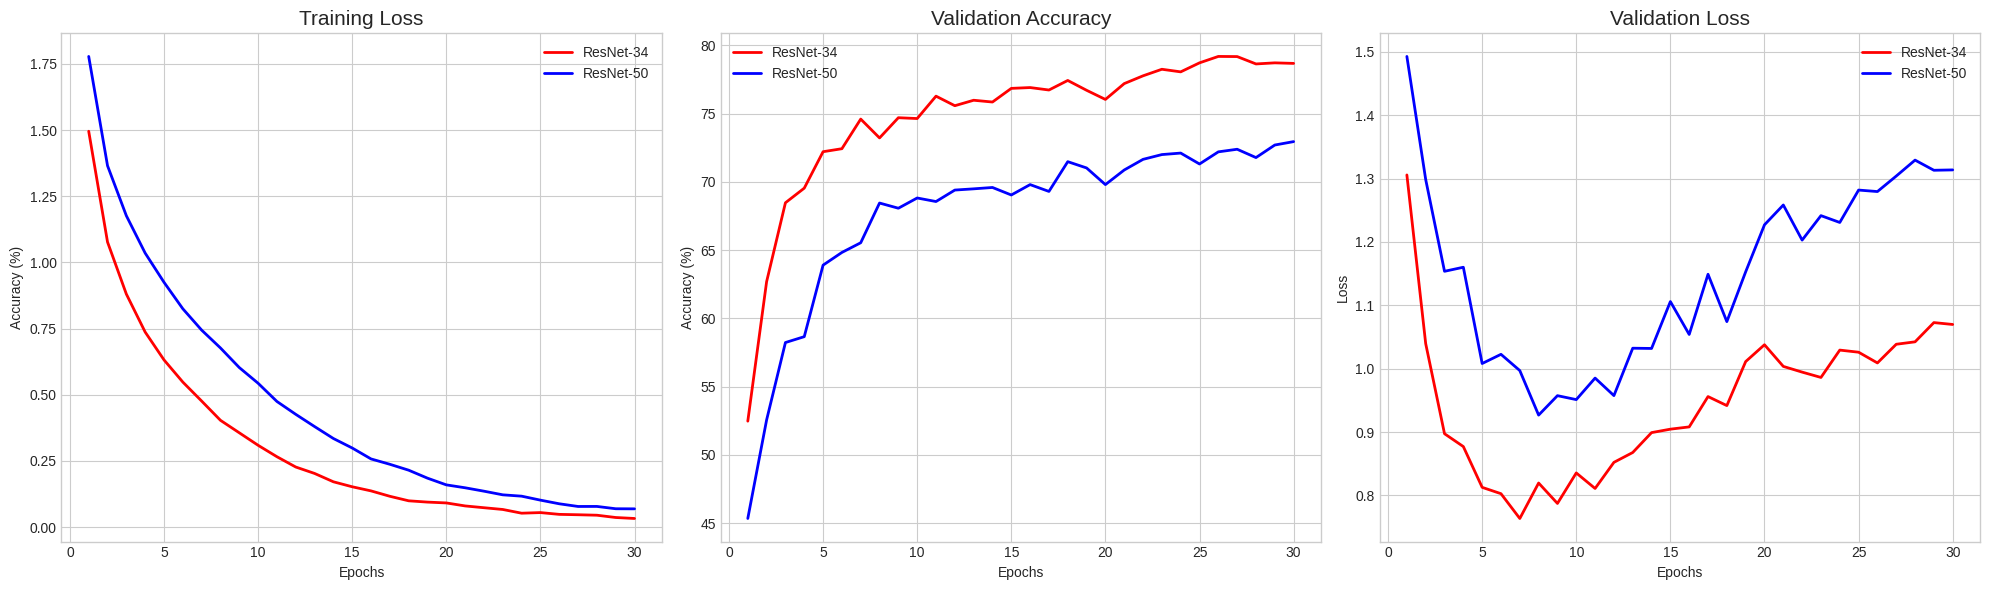

In [23]:
# 시각화

import matplotlib.pyplot as plt

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # 1행 3열 구성
epochs = range(1, len(ResNet_34_val_accuracy) + 1)

# --- 1. Training Accuracy (학습이 얼마나 잘 되는가) ---
axes[0].plot(epochs, ResNet_34_train_losses, 'r-', label='ResNet-34', linewidth=2)
axes[0].plot(epochs, ResNet_50_train_losses, 'b-', label='ResNet-50', linewidth=2)
axes[0].set_title('Training Loss', fontsize=15)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()

# --- 2. Validation Accuracy (실제 성능/일반화 능력) ---
axes[1].plot(epochs, ResNet_34_val_accuracy, 'r-', label='ResNet-34', linewidth=2)
axes[1].plot(epochs, ResNet_50_val_accuracy, 'b-', label='ResNet-50', linewidth=2)
axes[1].set_title('Validation Accuracy', fontsize=15)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

# --- 3. Validation Loss (학습의 안정성 및 과적합 징후) ---
axes[2].plot(epochs, ResNet_34_val_losses, 'r-', label='ResNet-34', linewidth=2)
axes[2].plot(epochs, ResNet_50_val_losses, 'b-', label='ResNet-50', linewidth=2)
axes[2].set_title('Validation Loss', fontsize=15)
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.tight_layout()
plt.show()

## 추가 실험(3)
- 추가실험(2)에 schedualer 추가
- 하이퍼파라미터 값 조정
- epoch 수 40으로 조정

In [7]:
# 데이터 로드 및 전처리
import torch.optim as optim


# 하이퍼파라미터 설정
BATCH_SIZE = 64
LR = 0.1  # 스케줄러를 쓸 때는 초기 LR을 높게 잡습니다.
EPOCH = 40

# 1. Transform 정의 (속도와 성능의 타협점 64x64)
train_transform = transforms.Compose([
    transforms.Resize((64, 64)), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 표준 정규화
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 2. 데이터셋 로드 (CIFAR-10으로 변경)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# 3. 데이터로더 설정 (에러 방지를 위해 num_workers=0)
batch_size = 128 
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(trainset)}개, 클래스: 10개")

학습 데이터: 50000개, 클래스: 10개


In [8]:
# scheduler 적용된 학습용 공통 함수
def train_model(model, model_name):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
    # 10 에폭마다 학습률을 0.1배로 감소시키는 스케줄러
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(EPOCH):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # 학습률 업데이트
        scheduler.step()

        # Validation 평가
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(testloader)
        epoch_val_acc = 100 * correct / total
        
        history['train_loss'].append(running_loss / len(trainloader))
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{EPOCH} - Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

    return history

In [9]:
# 학습 진행

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ResNet-34 학습
print("--- Training ResNet-34 ---")
resnet34 = build_resnet(34, 10)
history_34 = train_model(resnet34, "ResNet-34")

# ResNet-50 학습
print("\n--- Training ResNet-50 ---")
resnet50 = build_resnet(50, 10)
history_50 = train_model(resnet50, "ResNet-50")

--- Training ResNet-34 ---
[ResNet-34] Epoch 1/40 - Val Loss: 1.8112, Val Acc: 31.49%
[ResNet-34] Epoch 2/40 - Val Loss: 1.5011, Val Acc: 44.37%
[ResNet-34] Epoch 3/40 - Val Loss: 1.3980, Val Acc: 49.35%
[ResNet-34] Epoch 4/40 - Val Loss: 1.0918, Val Acc: 60.99%
[ResNet-34] Epoch 5/40 - Val Loss: 1.1190, Val Acc: 60.83%
[ResNet-34] Epoch 6/40 - Val Loss: 1.0470, Val Acc: 64.18%
[ResNet-34] Epoch 7/40 - Val Loss: 0.8821, Val Acc: 69.46%
[ResNet-34] Epoch 8/40 - Val Loss: 0.7621, Val Acc: 73.78%
[ResNet-34] Epoch 9/40 - Val Loss: 0.8644, Val Acc: 70.19%
[ResNet-34] Epoch 10/40 - Val Loss: 0.8765, Val Acc: 71.91%
[ResNet-34] Epoch 11/40 - Val Loss: 0.5480, Val Acc: 81.45%
[ResNet-34] Epoch 12/40 - Val Loss: 0.5316, Val Acc: 82.38%
[ResNet-34] Epoch 13/40 - Val Loss: 0.5488, Val Acc: 82.63%
[ResNet-34] Epoch 14/40 - Val Loss: 0.5596, Val Acc: 82.38%
[ResNet-34] Epoch 15/40 - Val Loss: 0.6005, Val Acc: 82.00%
[ResNet-34] Epoch 16/40 - Val Loss: 0.6130, Val Acc: 82.13%
[ResNet-34] Epoch 17/4

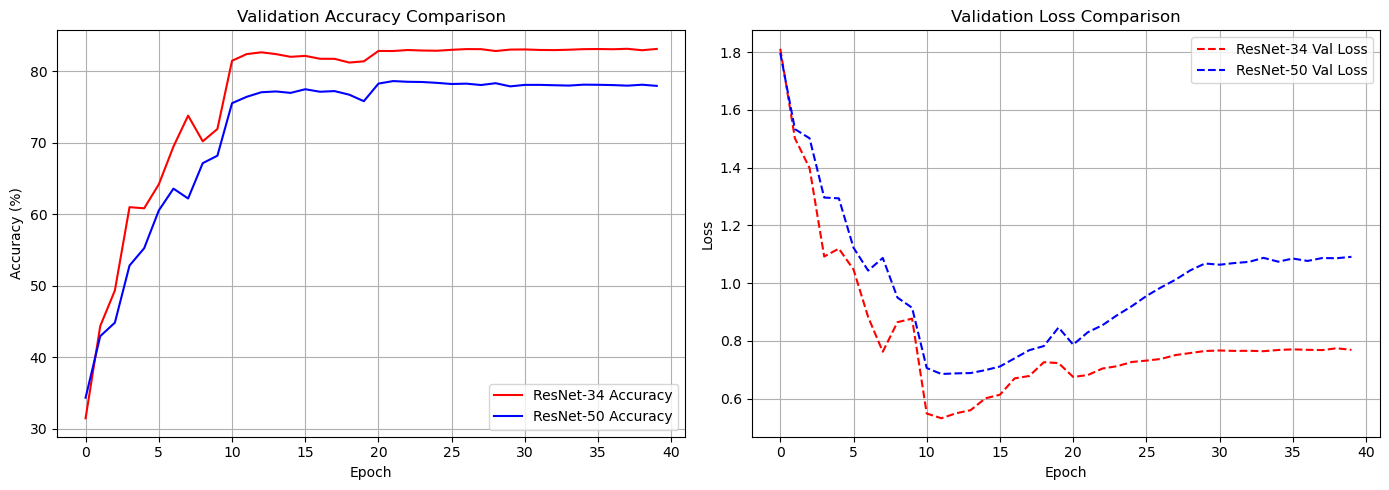

In [10]:
# 시각화

plt.figure(figsize=(14, 5))

# 1. Accuracy 비교
plt.subplot(1, 2, 1)
plt.plot(history_34['val_acc'], 'r-', label='ResNet-34 Accuracy')
plt.plot(history_50['val_acc'], 'b-', label='ResNet-50 Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# 2. Loss 비교
plt.subplot(1, 2, 2)
plt.plot(history_34['val_loss'], 'r--', label='ResNet-34 Val Loss')
plt.plot(history_50['val_loss'], 'b--', label='ResNet-50 Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 회고

### ResNet 모델 구현

- VGG에서는 블록함수를 함수의 형태로 실습 코드를 작성했으나, ResNet의 경우 BasicBlock과 Bottleneck이라는 클래스. 모듈로 구현해야 했다.
    - VGG와 달리, ResNet은 skip connection의 구조를 가지고 있어 **입력값을 보존했다가 나중에 더해주는 잔차 연결 구조**를 살려야 했다.
    - 함수형은 출력이 다음 층의 입력으로만 전달되지만, ResNet은 입력이 출력을 건너뛰어 합쳐지는 **비선형적 흐름**이 있어 이를 변수로 저장해두기 쉬운 클래스 구조를 사용하게 되었음.
- VGG에서 하나의 블록함수를 만든 것과 달리, ResNet은 34, 50 각각의 모듈을 만들었다.
    - 블럭 내의 구성이 달랐기 때문

### ResNet-34와 ResNet-50 비교 결과

- 우선, ResNet-34를 학습시킨 결과만 봐도 14 에폭만에 100%의 training accuracy를 보였는데, Validation accuracy는 30%에 못 미치는 수치를 보임으로써 과적합을 확인할 수 있었다.
- 즉, 준비한 데이터 (Oxford-IIIT Pet)가 모델에 비해 많이 부족하다는 판단을 하게 됨.
- ResNet-50은 34보다도 훨씬 복잡한 구조를 가지고 있어, 적은 양의 데이터로 복잡한 모델을 학습시키다보니 오히려 성능이 더 안 좋은 모습을 보였다.
- 논문과 같이 skip connection을 도입해 레이어가 깊은 모델이 레이어가 낮은 모델보다 좋은 성능을 보인다는 것을 증명하기에는
    - 데이터셋 자체가 너무 적은 양이었고,
    - 시간 관계 상 에폭 수도 모델이 충분히 학습하기에 적합한 양이 아니었다.
    - 그래서, 아쉽지만 논문과 같은 결과는 보지 못함

### ResNet과 PlainNet 비교

- Accuracy 값을 보면 분명히 ResNet이 PlainNet보다 좋은 성능을 보임을 명확히 확인할 수 있었다
    - ablation study의 성과는 얻을 수 있었음
- 단, Validation loss의 경우 앞에서 확인한 부족한 데이터와 복잡한 모델이라는 문제점을 포함해 새로운 문제를 보였다.
- 바로 ResNet 모델 쪽에서 loss값이 폭주하는 듯한 그래프 양상을 보인 것이다.
    - 그나마 ResNet-34는 중간에 치솟았다가 다시 내려오는 모습을 보였지만,
    - ResNet-50은 처음엔 빠른 속도로 loss값이 줄다가 8 에폭부터 점차 오르더니 마지막엔 폭주하며 끝났다.
    - 이를 통해. 이 실험의 문제에 Learning Rate Scheduler 나 가중치 규제 와 같은 최적화 기법을 사용하지 못하고 고정된 값을 사용한 부분이 적은 양의 데이터와 복잡한 모델 관계의 문제를 더 악화 시킨 것을 확인할 수 있었다.

### 추가 실험

- ResNet과 PlainNet을 비교하는 ablation study는 예상한 결과를 얻었지만, ResNet 논문이 보여준 성과를 전혀 얻지 못한 부분에서 아쉬움을 느꼈습니다.
- 여러가지 문제점 중 가장 중요하다고 큰 부분인 데이터셋 변경을 진행하고 에폭 수를 30으로 늘리기로 결정함

#### 1차 시도

- Oxford 데이터를 증강시켜 사용할 지, 아예 새로운 데이터세트를 이용할 지에 대한 고민을 했음
    - 하지만, Oxford 데이터를 증강 시켜도 기본적으로 적은 데이터 양을 극복하기엔 어렵다고 판단했다.
    - 또한 증강시킨 데이터도 모델이 금방 학습할 정도라는 생각이 들었고, 적은 에폭 수에서는 오히려 더 모델에게 혼란을 가져다 줄 수 있다는 판단을 함.
        - 제한된 샘플 수 내에서 데이터 증강만으로는 모델의 복잡도를 감당하기에 데이터의 다양성이 여전히 부족하다고 생각
- 1차 시도에는 CIFAR100 을 사용하려 했으나, 입력 이미지 크기를 224로 조정하고, num_workers=2 로 하다보니 아예 `shared memory` 문제가 발생해 진행할 수가 없었음
    - 입력 크기가 커질수록 CPU가 처리해야 할 데이터 양이 기하급수적으로 늘어나고, 이를 병렬로 처리하려는 과정에서 `bus error` 가 발생한 것으로 파악됨

#### 2차 시도

- 2차 시도로는 시간 문제도 있고 CIFAR100 데이터셋도 안되다보니 이용할 수 있는 데이터세트에 한계를 느껴서.
- 이미지 입력 사이즈도 작고 클래스도 적지만 속도와 성능의 trade off를 하기에 그나마 적합하다고 생각되는 실습에서 사용했던 CIFAR10 데이터세트를 사용해보기로 결정했다.
- 결과:
    - 과적합 문제도 나름 해결되었고,
    - 성능이 심하게 안좋았던 ResNet 50도 이전 시도에 비해 안정된 모습을 보임
    - validation loss 폭주 문제도 이전보다 안정됨

#### 3차 시도

- 2차 시도에 Scheduler를 더한 결과도 확인해보고자 했다
    - Oxford 데이터를 사용하지 않은 이유: 200장이라는 너무 작은 양의 데이터이기에 scheduler를 도입한다고 해도 큰 성과는 없을 것이라 판단.
- 결과:
    - 여전히 앞의 실험들과 마찬가지로 ResNet34의 성능이 더 좋은 모습을 보임.
      하지만, 이전의 실험들에 비해서는 그 차이가 완화된 모습을 확인할 수 있었음.
    - 또한 두 모델 모두 11 에포크와 21 에포크 지점에서 급격히 상승하는 모습을 보였고 이를 통해 스케줄러의 효과를 확인할 수 있었다.
- 왜 이런 결과(34가 50보다 좋은 성능)가 나왔을까?
    - 데이터 규모 대비 모델의 체급이 가장 큰 이유라는 생각이 들었다.
    - 즉, CIFAR-10 데이터셋 환경에서는 ResNet-50이라는 모델의 체급, 방대한 파라미터가 오히려 학습 데이터를 너무 과하게 암기하게 만들었고, 그 결과 테스트 데이터에 대한 일반화 성능이 ResNet-34보다 떨어지는 현상이 일어난 것 같다.

#### 위의 언급한 내용 외 깨달은 점
- 논문에서 사용한 모델의 구성을 구현하더라도 사용하는 데이터셋에 따라 전혀 다른 결과를 얻을 수 있다는 것을 깨달았다.
- 그만큼, 모델의 학습에 있어 데이터셋의 중요도를 확실히 알 수 있었고.
- 모델과 데이터셋의 균형이 맞아야 한다는 것도 다시금 깨달을 수 있었다.